# 02 — Feature Engineering

Calls the single shared entry point, `pl_predictor.features.build.build_training_frame`, that every consumer (training, backtesting, the Streamlit app) uses — so this notebook can never drift out of sync with what actually gets trained.

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')

from pl_predictor.features.build import build_training_frame

df, feature_cols = build_training_frame()
print(df.shape, len(feature_cols))

(3040, 400) 210


In [2]:
df[['date', 'team_home', 'team_away', 'confidence_home', 'confidence_away'] + feature_cols[:6]].head()

,date,team_home,team_away,confidence_home,confidence_away,home_last_3_goals_for,home_last_5_goals_for,home_last_10_goals_for,home_last_3_goals_against,home_last_5_goals_against,home_last_10_goals_against
0,2018-08-10,Man United,Leicester,none,none,1.431598,1.432174,1.433869,1.428457,1.428036,1.426301
1,2018-08-11,Bournemouth,Cardiff,none,none,1.431598,1.432174,1.433869,1.428457,1.428036,1.426301
2,2018-08-11,Fulham,Crystal Palace,none,none,1.431598,1.432174,1.433869,1.428457,1.428036,1.426301
3,2018-08-11,Huddersfield,Chelsea,none,none,1.431598,1.432174,1.433869,1.428457,1.428036,1.426301
4,2018-08-11,Newcastle,Tottenham,none,none,1.431598,1.432174,1.433869,1.428457,1.428036,1.426301


## Missing-value check

A handful of NaNs are expected (e.g. `h2h_*` before two teams have ever met in the loaded window) — but rolling-form columns should be fully filled thanks to the cold-start blend.

In [3]:
df[feature_cols].isna().mean().sort_values(ascending=False).head(15)

h2h_home_win_rate                  0.126974
h2h_home_goal_diff_avg             0.126974
rest_days_away                     0.005263
rest_days_home                     0.004605
home_last_3_goals_for              0.000000
away_home_last_10_goals_against    0.000000
away_home_last_3_goals_for         0.000000
away_away_last_3_goals_for         0.000000
away_home_last_5_goals_for         0.000000
away_away_last_5_goals_for         0.000000
away_home_last_10_goals_for        0.000000
away_away_last_10_goals_for        0.000000
away_home_last_3_goals_against     0.000000
away_away_last_3_goals_against     0.000000
away_home_last_5_goals_against     0.000000
dtype: float64

## One team's rolling form over time

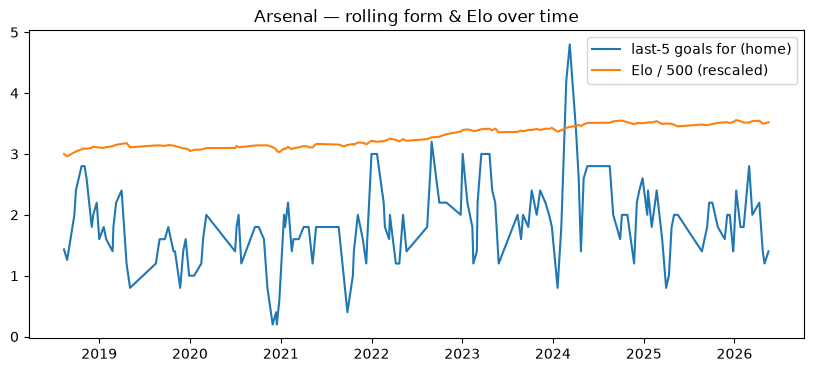

In [4]:
import matplotlib.pyplot as plt

team = 'Arsenal'
mask = df['team_home'] == team
plt.figure(figsize=(10, 4))
plt.plot(df.loc[mask, 'date'], df.loc[mask, 'home_last_5_goals_for'], label='last-5 goals for (home)')
plt.plot(df.loc[mask, 'date'], df.loc[mask, 'elo_home'] / 500, label='Elo / 500 (rescaled)')
plt.legend(); plt.title(f'{team} — rolling form & Elo over time'); plt.show()